## Import Library & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [2]:
df = pd.read_csv("us_accidents_2020.csv")

In [3]:
df.head()

,Severity,Start_Time,End_Time,Distance(mi),City,County,State,Temperature(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Direction,Wind_Speed(mph),Precipitation(in),Weather_Condition,Amenity,Bump,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Astronomical_Twilight,Year,Duration,Hour,Month,Day,Road_Features
0,2,2020-12-28 05:55:31,2021-01-18 05:00:00,0.46,Atlantic City,Atlantic,NJ,43.0,74.0,30.13,10.0,S,8.0,0.0,clear,0,0,0,0,0,0,0,0,0,0,0,0,Day,2020,3000.000000,5,12,0,0
1,3,2020-12-31 22:57:02,2021-01-01 00:29:02,0.00,Addison,DuPage,IL,20.0,81.0,29.59,7.0,CALM,0.0,0.0,clear,0,0,0,0,0,0,0,0,0,0,0,0,Night,2020,92.000000,22,12,3,0
2,3,2020-12-31 22:03:27,2021-01-01 01:43:05,0.00,Posen,Cook,IL,22.0,91.0,29.67,10.0,E,3.0,0.0,clear,0,0,0,0,0,0,0,0,0,0,0,0,Night,2020,219.633333,22,12,3,0
3,3,2020-12-31 22:58:36,2021-01-01 01:02:45,0.00,Chicago,Cook,IL,27.0,72.0,29.67,10.0,CALM,0.0,0.0,clear,0,0,1,0,0,0,0,0,0,0,0,1,Night,2020,124.150000,22,12,3,2
4,2,2020-12-31 23:32:07,2021-01-01 00:51:14,0.00,Denver,Denver,CO,28.0,69.0,24.39,10.0,CALM,0.0,0.0,clear,0,0,1,0,0,0,0,0,0,0,0,1,Night,2020,79.116667,23,12,3,2


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1178913 entries, 0 to 1178912
Data columns (total 34 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Severity               1178913 non-null  int64  
 1   Start_Time             1178913 non-null  object 
 2   End_Time               1178913 non-null  object 
 3   Distance(mi)           1178913 non-null  float64
 4   City                   1178913 non-null  object 
 5   County                 1178913 non-null  object 
 6   State                  1178913 non-null  object 
 7   Temperature(F)         1178913 non-null  float64
 8   Humidity(%)            1178913 non-null  float64
 9   Pressure(in)           1178913 non-null  float64
 10  Visibility(mi)         1178913 non-null  float64
 11  Wind_Direction         1178913 non-null  object 
 12  Wind_Speed(mph)        1178913 non-null  float64
 13  Precipitation(in)      1178913 non-null  float64
 14  Weather_Condition 

In [5]:
print(df.isna().sum())

Severity                 0
Start_Time               0
End_Time                 0
Distance(mi)             0
City                     0
County                   0
State                    0
Temperature(F)           0
Humidity(%)              0
Pressure(in)             0
Visibility(mi)           0
Wind_Direction           0
Wind_Speed(mph)          0
Precipitation(in)        0
Weather_Condition        0
Amenity                  0
Bump                     0
Crossing                 0
Give_Way                 0
Junction                 0
No_Exit                  0
Railway                  0
Roundabout               0
Station                  0
Stop                     0
Traffic_Calming          0
Traffic_Signal           0
Astronomical_Twilight    0
Year                     0
Duration                 0
Hour                     0
Month                    0
Day                      0
Road_Features            0
dtype: int64


In [6]:
df = df.drop(columns=["Start_Time", "End_Time", "Year"])

In [7]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include='object').columns

#Preproccessing

## Encoding

In [8]:
print(df[cat_cols].nunique().sort_values(ascending=False))

City                     9541
County                   1565
State                      49
Wind_Direction             10
Weather_Condition           6
Astronomical_Twilight       2
dtype: int64


In [9]:
le_cols = ["City", "County", "State"]
onehot_cols = ["Weather_Condition", "Wind_Direction", "Astronomical_Twilight"]

In [10]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in le_cols:
    df[col] = le.fit_transform(df[col])

In [11]:
df = pd.get_dummies(
    df,
    columns=onehot_cols,
    drop_first=True
)

In [12]:
print(df.dtypes)

Severity                            int64
Distance(mi)                      float64
City                                int64
County                              int64
State                               int64
Temperature(F)                    float64
Humidity(%)                       float64
Pressure(in)                      float64
Visibility(mi)                    float64
Wind_Speed(mph)                   float64
Precipitation(in)                 float64
Amenity                             int64
Bump                                int64
Crossing                            int64
Give_Way                            int64
Junction                            int64
No_Exit                             int64
Railway                             int64
Roundabout                          int64
Station                             int64
Stop                                int64
Traffic_Calming                     int64
Traffic_Signal                      int64
Duration                          

In [13]:
print(df.shape)

(1178913, 43)


In [14]:
df.head(10)

,Severity,Distance(mi),City,County,State,Temperature(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in),Amenity,Bump,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Duration,Hour,Month,Day,Road_Features,Weather_Condition_fog,Weather_Condition_hail,Weather_Condition_rain,Weather_Condition_snow,Weather_Condition_thunderstorm,Wind_Direction_E,Wind_Direction_N,Wind_Direction_NE,Wind_Direction_NW,Wind_Direction_S,Wind_Direction_SE,Wind_Direction_SW,Wind_Direction_VAR,Wind_Direction_W,Astronomical_Twilight_Night
0,2,0.46,313,61,29,43.0,74.0,30.13,10.0,8.0,0.00,0,0,0,0,0,0,0,0,0,0,0,0,3000.000000,5,12,0,0,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False
1,3,0.00,30,426,12,20.0,81.0,29.59,7.0,0.0,0.00,0,0,0,0,0,0,0,0,0,0,0,0,92.000000,22,12,3,0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
2,3,0.00,6862,331,12,22.0,91.0,29.67,10.0,3.0,0.00,0,0,0,0,0,0,0,0,0,0,0,0,219.633333,22,12,3,0,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True
3,3,0.00,1475,331,12,27.0,72.0,29.67,10.0,0.0,0.00,0,0,1,0,0,0,0,0,0,0,0,1,124.150000,22,12,3,2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
4,2,0.00,2112,399,4,28.0,69.0,24.39,10.0,0.0,0.00,0,0,1,0,0,0,0,0,0,0,0,1,79.116667,23,12,3,2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
5,3,0.43,2112,399,4,34.0,41.0,24.41,10.0,5.0,0.00,0,0,0,0,1,0,0,0,0,0,0,0,78.333333,23,12,3,1,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True
6,2,0.00,7658,730,45,46.0,89.0,29.43,7.0,10.0,0.02,0,0,1,0,0,0,0,0,0,0,0,1,81.300000,22,12,3,2,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True
7,2,0.00,7658,730,45,46.0,93.0,30.04,10.0,6.0,0.00,0,0,0,0,0,0,0,0,0,0,0,0,90.316667,23,12,3,0,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True
8,2,0.00,8170,1220,3,45.0,80.0,30.06,10.0,8.0,0.00,0,0,0,0,1,0,0,0,0,0,0,0,118.266667,20,12,3,1,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True
9,2,0.00,8170,1220,3,54.0,57.0,30.06,10.0,10.0,0.00,0,0,0,0,0,0,0,0,0,0,0,0,337.900000,17,12,3,0,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False


## Data Splitting

In [15]:
from sklearn.model_selection import train_test_split

target = "Severity"

X = df.drop(columns=[target])
y = df[target]

In [17]:
from imblearn.under_sampling import RandomUnderSampler

sam= RandomUnderSampler(random_state=0)
X_resampled_under , y_resampled_under = sam.fit_resample(X,y)
y_resampled_under.value_counts()

Severity
1    28371
2    28371
3    28371
4    28371
Name: count, dtype: int64

In [18]:
X_train_resampled, X_test_resampled, y_train_resampled, y_test_resampled = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [20]:
# Ambil kolom boolean (hasil one-hot)
binary_cols = [col for col in X_train_resampled.columns if X_train_resampled[col].dtype == 'bool']

numerical_features = [
    col for col in X_train_resampled.columns
    if col not in cat_cols
    and col not in binary_cols
]

categorical_features = [col for col in X.columns if col not in numerical_features]

## Feature Scaling

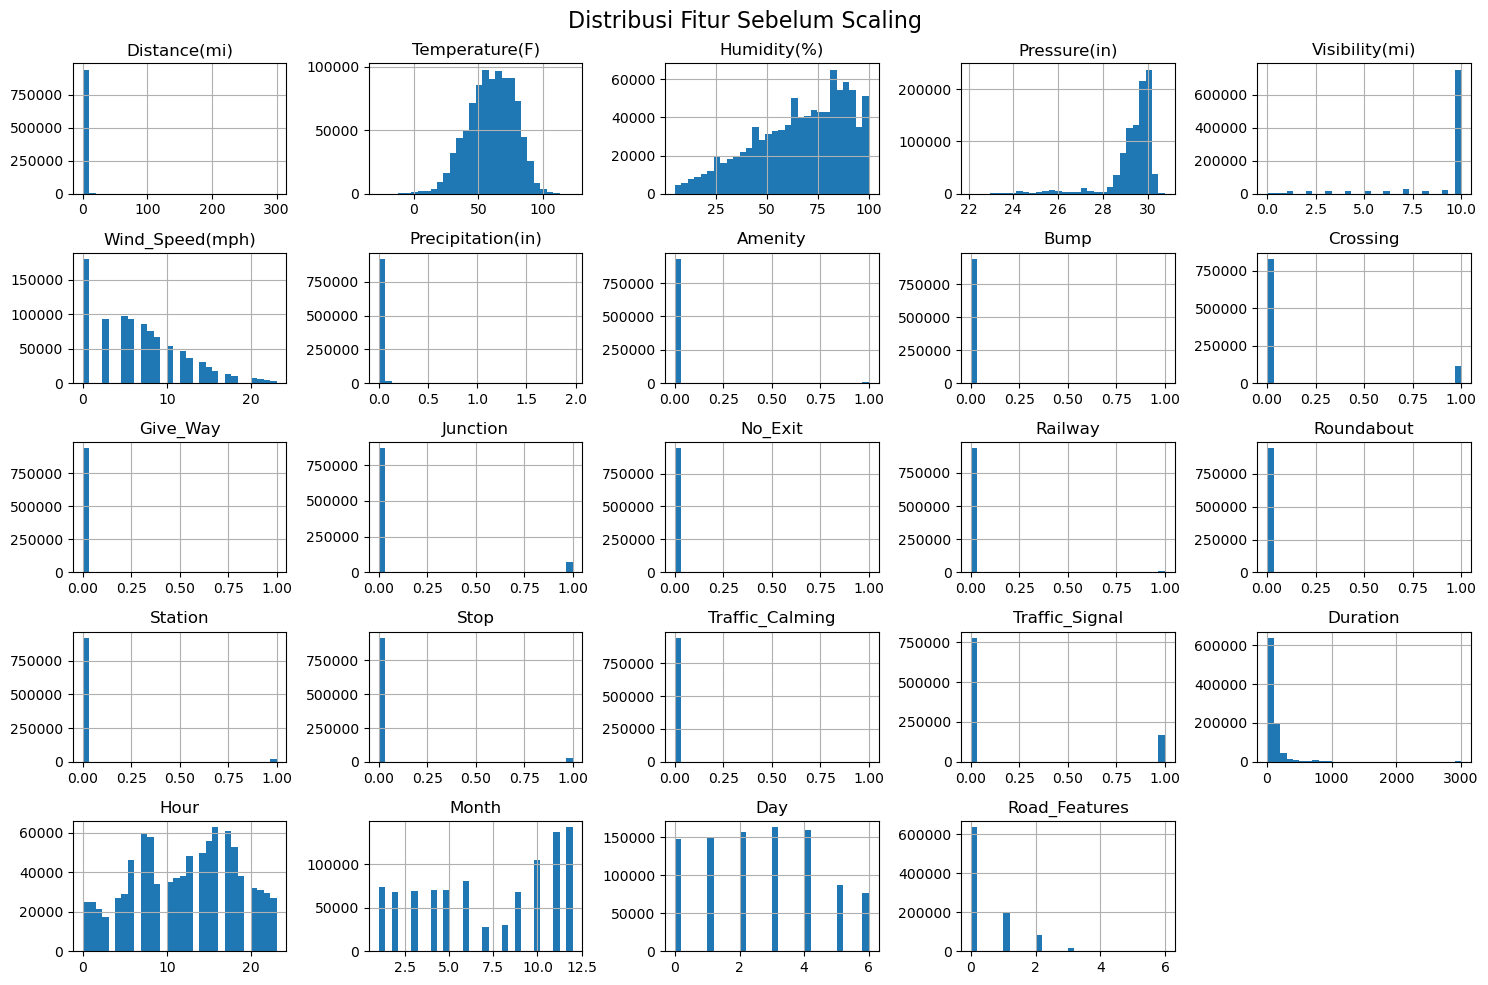

In [21]:
import matplotlib.pyplot as plt

# Plot beberapa fitur numerikal
X_train_resampled[numerical_features].hist(figsize=(15, 10), bins=30)
plt.suptitle("Distribusi Fitur Sebelum Scaling", fontsize=16)
plt.tight_layout()
plt.show()

In [23]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_train_scaled = X_train_resampled.copy()
X_test_scaled = X_test_resampled.copy()

X_train_scaled[numerical_features] = scaler.fit_transform(X_train_resampled[numerical_features])
X_test_scaled[numerical_features] = scaler.transform(X_test_resampled[numerical_features])

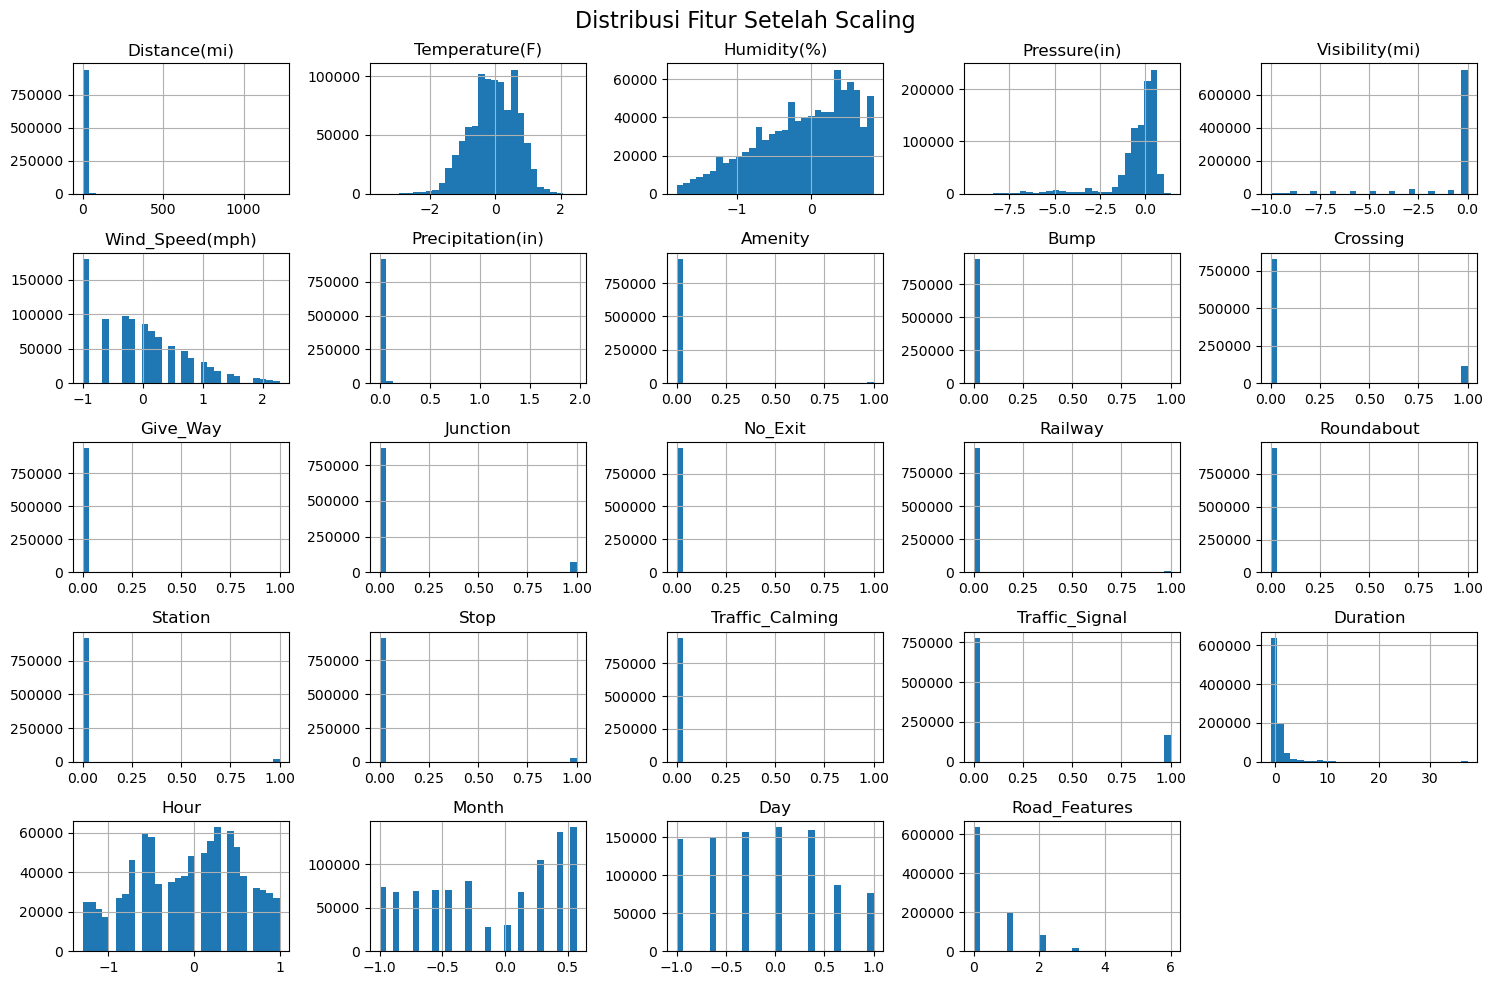

In [24]:
X_train_scaled[numerical_features].hist(figsize=(15, 10), bins=30)
plt.suptitle("Distribusi Fitur Setelah Scaling", fontsize=16)
plt.tight_layout()
plt.show()

#Modeling

In [25]:
!pip install xgboost lightgbm catboost optuna -q

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.model_selection import (cross_val_score, StratifiedKFold,
                                     learning_curve, train_test_split)
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED        = 42
CLASS_NAMES = ["1", "2", "3", "4"]
cv          = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

PALETTE = {
    "Logistic Regression": "#4C72B0",
    "Random Forest":       "#DD8452",
    "XGBoost":             "#55A868",
    "LightGBM":            "#C44E52",
}

print("Setup complete.")
print(f"X_train: {X_train_resampled.shape} | X_test: {X_test_resampled.shape}")
print(f"Class distribution (train):\n{pd.Series(y_train_resampled).value_counts()}")

Setup complete.
X_train: (943130, 42) | X_test: (235783, 42)
Class distribution (train):
Severity
2    747298
3    148281
4     24854
1     22697
Name: count, dtype: int64


### Helper Function

In [28]:
X_tr = X_train_resampled
y_tr = y_train_resampled

X_te = X_test_resampled
y_te = y_test_resampled

In [ ]:
def evaluate_model(model, X_tr, y_tr, X_te, y_te, name="Model"):
    model.fit(X_tr, y_tr)
    y_pred_tr = model.predict(X_tr)
    y_pred_te = model.predict(X_te)
    return {
        "Model":           name,
        "Train Acc":       accuracy_score(y_tr, y_pred_tr),
        "Test Acc":        accuracy_score(y_te, y_pred_te),
        "Test F1 (macro)": f1_score(y_te, y_pred_te, average="macro"),
        "Test Precision":  precision_score(y_te, y_pred_te, average="macro", zero_division=0),
        "Test Recall":     recall_score(y_te, y_pred_te, average="macro", zero_division=0),
        "CV Acc (mean)":   cross_val_score(model, X_tr, y_tr,
                                           cv=cv, scoring="accuracy").mean(),
    }, model


def plot_confusion_matrix(model, X_te, y_te, title="Confusion Matrix"):
    cm   = confusion_matrix(y_te, model.predict(X_te))
    disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(title, fontsize=13, fontweight="bold")
    plt.tight_layout(); plt.show()


def plot_learning_curve(estimator, X, y, title="Learning Curve", color="#4C72B0"):
    train_sizes, train_scores, val_scores = learning_curve(
        estimator, X, y,
        cv=cv, scoring="accuracy",
        train_sizes=np.linspace(0.1, 1.0, 8),
        n_jobs=2
    )
    tr_m, tr_s = train_scores.mean(axis=1), train_scores.std(axis=1)
    va_m, va_s = val_scores.mean(axis=1),   val_scores.std(axis=1)
    gap        = tr_m[-1] - va_m[-1]

    diagnosis = ("Overfitting"  if gap > 0.10 else
                 "Underfitting" if va_m[-1] < 0.65 else
                 "Good Fit")

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.fill_between(train_sizes, tr_m - tr_s, tr_m + tr_s, alpha=0.15, color=color)
    ax.fill_between(train_sizes, va_m - va_s, va_m + va_s, alpha=0.15, color="orange")
    ax.plot(train_sizes, tr_m, "o-", color=color,    label="Train Accuracy")
    ax.plot(train_sizes, va_m, "s-", color="orange", label="CV Accuracy")
    ax.set_title(f"{title}  |  {diagnosis}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Training Samples"); ax.set_ylabel("Accuracy")
    ax.set_ylim(0, 1.05); ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()
    return gap


def plot_train_vs_test(results_list):
    df_r = pd.DataFrame(results_list)
    x, w = np.arange(len(df_r)), 0.35
    fig, ax = plt.subplots(figsize=(10, 5))
    b1 = ax.bar(x - w/2, df_r["Train Acc"], w, label="Train Acc", color="#5B7BE9", edgecolor="white")
    b2 = ax.bar(x + w/2, df_r["Test Acc"],  w, label="Test Acc",  color="#F4A261", edgecolor="white")
    for b in [*b1, *b2]:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.005,
                f"{b.get_height():.3f}", ha="center", va="bottom", fontsize=8.5)
    ax.set_xticks(x); ax.set_xticklabels(df_r["Model"], rotation=20, ha="right")
    ax.set_ylim(0, 1.15); ax.set_ylabel("Accuracy")
    ax.set_title("Train vs. Test Accuracy — Overfitting Detector", fontsize=13, fontweight="bold")
    ax.legend(); ax.grid(axis="y", alpha=0.3)
    plt.tight_layout(); plt.show()

print("Helper functions ready.")

Helper functions ready.


### Logistic Regression

In [32]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

res_lr, model_lr = evaluate_model(
    lr, X_tr, y_tr, X_te, y_te,
    name="Logistic Regression"
)

res_lr

{'Model': 'Logistic Regression',
 'Train Acc': 0.7921824138771961,
 'Test Acc': 0.792398094858408,
 'Test F1 (macro)': 0.23389503486550514,
 'Test Precision': 0.46857325545652373,
 'Test Recall': 0.2556869448440185,
 'CV Acc (mean)': np.float64(nan)}

In [50]:
print(classification_report(y_te, model_lr.predict(X_te), target_names=CLASS_NAMES))

              precision    recall  f1-score   support

           1       0.24      0.01      0.01      5674
           2       0.80      1.00      0.88    186825
           3       0.44      0.02      0.03     37071
           4       0.41      0.00      0.01      6213

    accuracy                           0.79    235783
   macro avg       0.47      0.26      0.23    235783
weighted avg       0.71      0.79      0.71    235783



Confussion Matrix

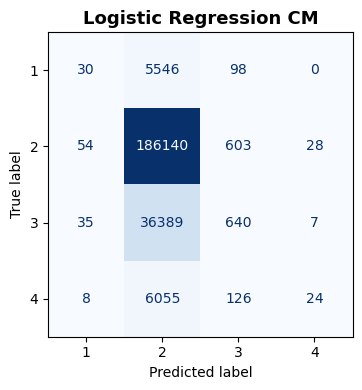

In [35]:
plot_confusion_matrix(model_lr, X_te, y_te, title="Logistic Regression CM")

Learning Curve

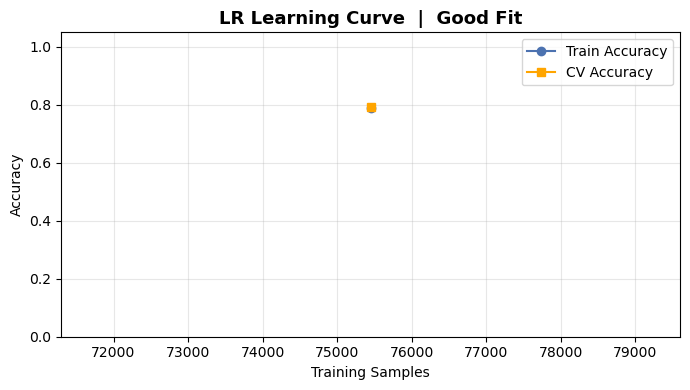

np.float64(nan)

In [38]:
plot_learning_curve(lr, X_tr, y_tr, title="LR Learning Curve")

### Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

res_rf, model_rf = evaluate_model(
    rf, X_tr, y_tr, X_te, y_te,
    name="Random Forest"
)

res_rf

{'Model': 'Random Forest',
 'Train Acc': 0.8058666355645563,
 'Test Acc': 0.8052192057951592,
 'Test F1 (macro)': 0.33179576210746375,
 'Test Precision': 0.8659875471184149,
 'Test Recall': 0.3126587270918949,
 'CV Acc (mean)': np.float64(0.8053120990743586)}

In [48]:
print(classification_report(y_te, model_rf.predict(X_te), target_names=CLASS_NAMES))

              precision    recall  f1-score   support

           1       0.92      0.18      0.30      5674
           2       0.81      1.00      0.89    186825
           3       0.77      0.07      0.12     37071
           4       0.97      0.00      0.01      6213

    accuracy                           0.81    235783
   macro avg       0.87      0.31      0.33    235783
weighted avg       0.81      0.81      0.73    235783



Confussion Matrix

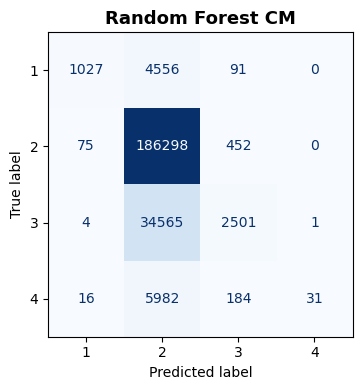

In [47]:
plot_confusion_matrix(model_rf, X_te, y_te, title="Random Forest CM")